In [ ]:
import osmnx as ox
import geopandas as gpd
import hvplot.pandas

: 

In [11]:
gric = ox.geocode_to_gdf(
    "Colorado State University, Fort Collins, USA"
)

gric.head()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-105.10968 40.57637, -105.1091...",-105.109676,40.552786,-105.072182,40.594754,328993255,relation,8539568,40.570657,-105.085399,amenity,university,30,0.547321,amenity,Colorado State University,"Colorado State University, Remington Street, F..."


<Axes: >

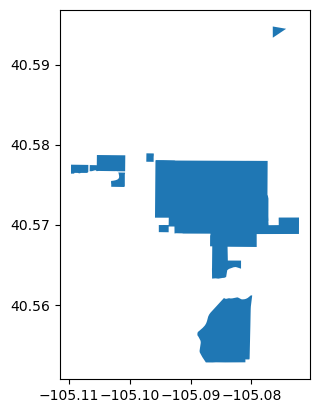

In [12]:
gric.plot()

In [13]:
gric.to_file("gric_boundary.shp")
boundary_gdf = gpd.read_file("gric_boundary.shp")

/tmp/ipykernel_38331/2165521529.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gric.to_file("gric_boundary.shp")
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'addresstype' to 'addresstyp'
  ogr_write(
/opt/conda/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'display_name' to 'display_na'
  ogr_write(


In [14]:
boundary_gdf.head()
boundary_gdf.columns
boundary_gdf.hvplot(
    geo=True,
    tiles="EsriImagery",
    fill_color=None,
    line_color="blue",
    line_width=3,
    frame_width=700,
    title="Colorado State University Boundary Map",
)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

In [ ]:
%store boundary_gdf

: 

In [1]:
# Import libraries
import json
from glob import glob

import earthpy # work with spatial data
import geopandas as gpd
import hvplot.xarray
import hvplot.pandas
import pandas as pd
import rioxarray as rxr
import xarray as xr

In [2]:
project = earthpy.Project("Gila River Vegetation", dirname="gila-river-vegetation")
project.get_data()

In [3]:
project.project_dir

PosixPath('/workspaces/data/gila-river-vegetation')

In [4]:
# Get a sorted list of NDVI tif file paths
ndvi_paths = sorted(list(project.project_dir.rglob('*NDVI*.tif')))

# Display the first and last three files paths to check the pattern
ndvi_paths[:3], ndvi_paths[-3:]

([PosixPath('/workspaces/data/gila-river-vegetation/gila-river-ndvi/MOD13Q1.061_2001137_to_2022244/MOD13Q1.061__250m_16_days_NDVI_doy2001145000000_aid0001.tif'),
  PosixPath('/workspaces/data/gila-river-vegetation/gila-river-ndvi/MOD13Q1.061_2001137_to_2022244/MOD13Q1.061__250m_16_days_NDVI_doy2001161000000_aid0001.tif'),
  PosixPath('/workspaces/data/gila-river-vegetation/gila-river-ndvi/MOD13Q1.061_2001137_to_2022244/MOD13Q1.061__250m_16_days_NDVI_doy2001177000000_aid0001.tif')],
 [PosixPath('/workspaces/data/gila-river-vegetation/gila-river-ndvi/MOD13Q1.061_2001137_to_2022244/MOD13Q1.061__250m_16_days_NDVI_doy2022209000000_aid0001.tif'),
  PosixPath('/workspaces/data/gila-river-vegetation/gila-river-ndvi/MOD13Q1.061_2001137_to_2022244/MOD13Q1.061__250m_16_days_NDVI_doy2022225000000_aid0001.tif'),
  PosixPath('/workspaces/data/gila-river-vegetation/gila-river-ndvi/MOD13Q1.061_2001137_to_2022244/MOD13Q1.061__250m_16_days_NDVI_doy2022241000000_aid0001.tif')])